# Customer Churn Prediction - End-to-End ML Project
**Author:** Zujaja

Predict whether a customer will churn based on account, service, and usage data.

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

# Saving
import joblib

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [3]:
df = pd.read_csv("customer_churn_data.csv")
df.head()

,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


In [4]:
print("FIRST 5 ROWS")
display(df.head())

print("\nLAST 5 ROWS")
display(df.tail())

FIRST 5 ROWS


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,CUST10001,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,CUST10002,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,CUST10003,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,CUST10004,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,CUST10005,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes



LAST 5 ROWS


,customer_id,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
1215,CUST10722,76,Female,South,48,61.37,2896.21,Month-to-month,DSL,Yes,Yes,Yes,Electronic check,1,1,93.5,Yes
1216,CUST11129,53,Male,East,9,86.36,716.92,One year,Fiber optic,Yes,Yes,Yes,NaN,0,2,387.3,No
1217,CUST10400,37,Female,South,69,78.02,5132.74,One year,Fiber optic,No,Yes,Yes,Bank transfer,1,1,387.6,No
1218,CUST10695,23,Male,South,56,84.87,4533.03,One year,Fiber optic,No,No,No,Bank transfer,2,3,304.3,No
1219,CUST10110,62,Female,West,45,89.86,3730.49,Two year,Fiber optic,No,Yes,Yes,Electronic check,0,4,308.0,No


In [5]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nInfo:")
df.info()

Shape: (1220, 17)

Columns: ['customer_id', 'age', 'gender', 'region', 'tenure_months', 'monthly_charges', 'total_charges', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb', 'churn']

Data types:
 customer_id                 object
age                          int64
gender                      object
region                      object
tenure_months                int64
monthly_charges            float64
total_charges              float64
contract_type               object
internet_service            object
tech_support                object
online_security             object
paperless_billing           object
payment_method              object
num_support_calls            int64
late_payments_last_year      int64
avg_monthly_usage_gb       float64
churn                       object
dtype: object

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1220

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1220,1200,CUST10400,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1220.0,NaN,NaN,NaN,49.309016,18.125678,18.0,34.0,49.5,65.0,80.0
gender,1220,2,Male,625,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1220,4,South,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure_months,1220.0,NaN,NaN,NaN,36.956557,20.51256,1.0,19.0,38.0,55.0,72.0
monthly_charges,1198.0,NaN,NaN,NaN,66.509474,24.295211,18.0,50.0475,69.02,86.465,118.58
total_charges,1187.0,NaN,NaN,NaN,2421.133437,1681.896803,12.6,1011.74,2120.45,3619.765,7579.28
contract_type,1220,3,Month-to-month,679,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet_service,1220,3,Fiber optic,563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tech_support,1194,3,No,582,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Unique values in categoricals
cat_cols = df.select_dtypes(include="object").columns
for c in cat_cols:
    print(f"\n{c}: {df[c].unique()}")

# Target distribution
print("\nChurn distribution:\n", df["churn"].value_counts())
print("\nChurn %:\n", df["churn"].value_counts(normalize=True) * 100)

Missing values per column:
 customer_id                 0
age                         0
gender                      0
region                      0
tenure_months               0
monthly_charges            22
total_charges              33
contract_type               0
internet_service            0
tech_support               26
online_security            21
paperless_billing           0
payment_method             20
num_support_calls           0
late_payments_last_year     0
avg_monthly_usage_gb       24
churn                       0
dtype: int64

Total missing: 146

Duplicate rows: 20

customer_id: ['CUST10001' 'CUST10002' 'CUST10003' ... 'CUST11198' 'CUST11199'
 'CUST11200']

gender: ['Female' 'Male']

region: ['East' 'West' 'North' 'South']

contract_type: ['Two year' 'One year' 'Month-to-month']

internet_service: ['DSL' 'Fiber optic' 'No']

tech_support: ['Yes' 'No' 'No internet service' nan]

online_security: ['Yes' 'No' 'No internet service' nan]

paperless_billing: ['No' 'Yes']



## Data Cleaning Decisions

1. **Duplicates**: Drop exact duplicate rows (some `customer_id`s appear more than once at the end of the file). Keeping them would bias the model.
2. **Missing numeric values** (`monthly_charges`, `total_charges`, `avg_monthly_usage_gb`): Impute with the **median** — robust to outliers.
3. **Missing categorical values** (`tech_support`, `online_security`, `payment_method`): Impute with the **most frequent value (mode)**.
4. **`customer_id`**: Drop it — it's a unique identifier with no predictive signal and would cause overfitting.

In [9]:
df = df.drop_duplicates().reset_index(drop=True)
print("After dropping duplicates:", df.shape)

# Drop customer_id
df = df.drop(columns=["customer_id"])
df.head()

After dropping duplicates: (1200, 17)


,age,gender,region,tenure_months,monthly_charges,total_charges,contract_type,internet_service,tech_support,online_security,paperless_billing,payment_method,num_support_calls,late_payments_last_year,avg_monthly_usage_gb,churn
0,23,Female,East,45,65.65,2659.64,Two year,DSL,Yes,Yes,No,Electronic check,1,1,141.4,No
1,66,Male,East,43,105.10,4357.87,One year,Fiber optic,No,Yes,Yes,Electronic check,1,1,345.3,No
2,59,Female,West,16,61.12,1074.50,Month-to-month,DSL,No,Yes,Yes,Electronic check,1,1,160.2,Yes
3,45,Female,East,58,89.25,4973.26,One year,Fiber optic,Yes,Yes,Yes,Electronic check,3,1,461.5,No
4,45,Female,North,50,91.11,4580.38,Month-to-month,Fiber optic,Yes,Yes,Yes,Bank transfer,0,3,470.1,Yes


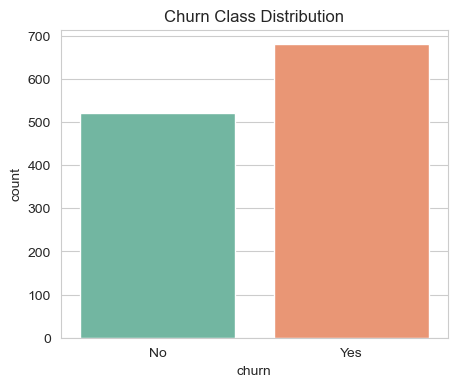

churn
Yes    56.666667
No     43.333333
Name: proportion, dtype: float64


In [10]:
plt.figure(figsize=(5,4))
sns.countplot(x="churn", data=df, palette="Set2")
plt.title("Churn Class Distribution")
plt.show()

print(df["churn"].value_counts(normalize=True)*100)

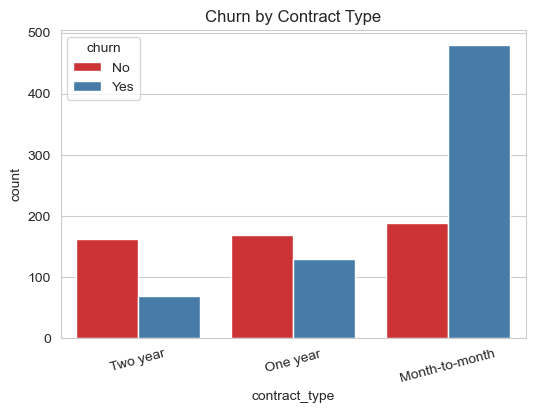

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x="contract_type", hue="churn", data=df, palette="Set1")
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

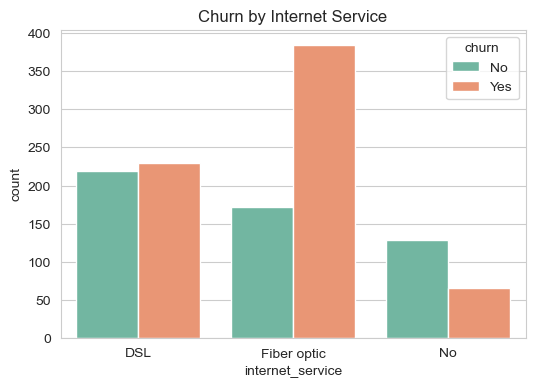

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="internet_service", hue="churn", data=df, palette="Set2")
plt.title("Churn by Internet Service")
plt.show()

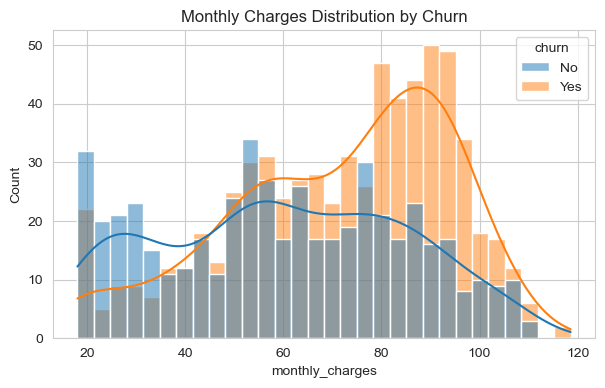

In [13]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="monthly_charges", hue="churn", kde=True, bins=30)
plt.title("Monthly Charges Distribution by Churn")
plt.show()

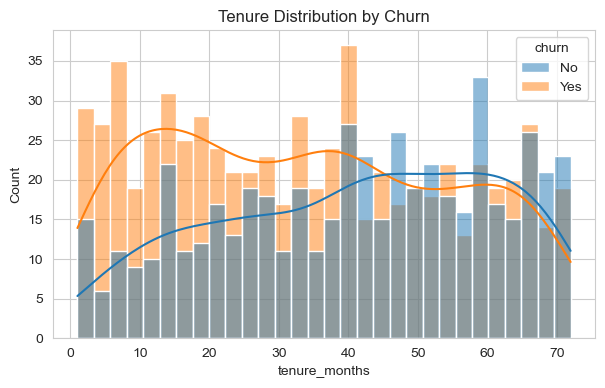

In [14]:
plt.figure(figsize=(7,4))
sns.histplot(data=df, x="tenure_months", hue="churn", kde=True, bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

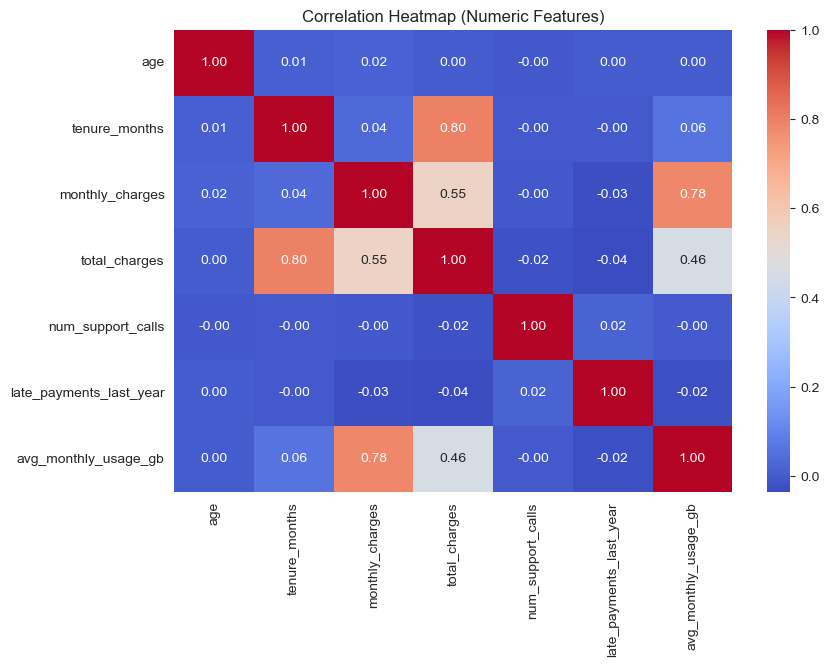

In [20]:
plt.figure(figsize=(9,6))
num_df = df.select_dtypes(include=np.number)
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

In [21]:
X = df.drop(columns=["churn"])
y = df["churn"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb']
Categorical: ['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method']


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(960, 15) (240, 15)


In [23]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [24]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=42))
])

log_reg.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("Both models trained.")

Both models trained.


In [25]:
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    print(f"===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_test, preds), 4))
    print("Precision:", round(precision_score(y_test, preds, pos_label="Yes"), 4))
    print("Recall   :", round(recall_score(y_test, preds, pos_label="Yes"), 4))
    print("F1 Score :", round(f1_score(y_test, preds, pos_label="Yes"), 4))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))
    print("\nClassification Report:\n",
          classification_report(y_test, preds))
    print("-"*50)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, pos_label="Yes"),
        "Recall": recall_score(y_test, preds, pos_label="Yes"),
        "F1": f1_score(y_test, preds, pos_label="Yes"),
    }

res_lr = evaluate_model("Logistic Regression", log_reg, X_test, y_test)
res_rf = evaluate_model("Random Forest", rf, X_test, y_test)

results_df = pd.DataFrame([res_lr, res_rf]).set_index("Model")
results_df

===== Logistic Regression =====
Accuracy : 0.7583
Precision: 0.7671
Recall   : 0.8235
F1 Score : 0.7943
Confusion Matrix:
 [[ 70  34]
 [ 24 112]]

Classification Report:
               precision    recall  f1-score   support

          No       0.74      0.67      0.71       104
         Yes       0.77      0.82      0.79       136

    accuracy                           0.76       240
   macro avg       0.76      0.75      0.75       240
weighted avg       0.76      0.76      0.76       240

--------------------------------------------------
===== Random Forest =====
Accuracy : 0.7125
Precision: 0.741
Recall   : 0.7574
F1 Score : 0.7491
Confusion Matrix:
 [[ 68  36]
 [ 33 103]]

Classification Report:
               precision    recall  f1-score   support

          No       0.67      0.65      0.66       104
         Yes       0.74      0.76      0.75       136

    accuracy                           0.71       240
   macro avg       0.71      0.71      0.71       240
weighted avg   

,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.758333,0.767123,0.823529,0.794326
Random Forest,0.712500,0.741007,0.757353,0.749091


## Model Selection

We compare Logistic Regression and Random Forest using Accuracy, Precision, Recall and F1.

- Logistic Regression gives a simple, interpretable baseline.
- Random Forest usually captures non-linear interactions better.

**Selection rule:** Choose the model with the better **F1-score on churn = Yes**, because churn is the minority class and we care about catching churners (Recall) without too many false alarms (Precision). We do NOT pick solely on training accuracy.

In [29]:
# Pick the model with higher F1 on churn
best_model = rf if res_rf["F1"] >= res_lr["F1"] else log_reg
best_name = "Random Forest" if best_model is rf else "Logistic Regression"
print("Selected model:", best_name)



Selected model: Logistic Regression


In [30]:
joblib.dump(best_model, "churn_pipeline.pkl")
print("Saved churn_pipeline.pkl")

Saved churn_pipeline.pkl


In [27]:
loaded = joblib.load("churn_pipeline.pkl")

sample = X_test.iloc[[0]]
print("Sample input:\n", sample)
print("Prediction:", loaded.predict(sample)[0])
if hasattr(loaded, "predict_proba"):
    print("Probability:", loaded.predict_proba(sample))

Sample input:
       age gender region  tenure_months  monthly_charges  total_charges  \
1140   73   Male  North             19            42.43         758.01   

       contract_type internet_service tech_support online_security  \
1140  Month-to-month              DSL          Yes              No   

     paperless_billing payment_method  num_support_calls  \
1140                No   Mailed check                  3   

      late_payments_last_year  avg_monthly_usage_gb  
1140                        0                 106.4  
Prediction: Yes
Probability: [[0.39730673 0.60269327]]


In [28]:
# Optional: save the column list so the app builds identical input
import json
schema = {
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categorical_options": {c: sorted(df[c].dropna().unique().tolist()) for c in categorical_features}
}
with open("schema.json", "w") as f:
    json.dump(schema, f, indent=2)
print(schema)

{'numeric_features': ['age', 'tenure_months', 'monthly_charges', 'total_charges', 'num_support_calls', 'late_payments_last_year', 'avg_monthly_usage_gb'], 'categorical_features': ['gender', 'region', 'contract_type', 'internet_service', 'tech_support', 'online_security', 'paperless_billing', 'payment_method'], 'categorical_options': {'gender': ['Female', 'Male'], 'region': ['East', 'North', 'South', 'West'], 'contract_type': ['Month-to-month', 'One year', 'Two year'], 'internet_service': ['DSL', 'Fiber optic', 'No'], 'tech_support': ['No', 'No internet service', 'Yes'], 'online_security': ['No', 'No internet service', 'Yes'], 'paperless_billing': ['No', 'Yes'], 'payment_method': ['Bank transfer', 'Credit card', 'Electronic check', 'Mailed check']}}
